In [78]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from tqdm import tqdm
from scipy.cluster.hierarchy import  linkage,dendrogram
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [61]:
df=pd.read_csv("../Datasets/milk.csv",index_col=0)
# wap a1 and b1 is very way ,do not match ,variance is not high

In [62]:
print(df.head())

           water  protein  fat  lactose   ash
Animal                                       
HORSE       90.1      2.6  1.0      6.9  0.35
ORANGUTAN   88.5      1.4  3.5      6.0  0.24
MONKEY      88.4      2.2  2.7      6.4  0.18
DONKEY      90.3      1.7  1.4      6.2  0.40
HIPPO       90.4      0.6  4.5      4.4  0.10


In [63]:
scaler=StandardScaler().set_output(transform="pandas")
df=scaler.fit_transform(df)
print(df.head())
df_milk_scale=scaler.fit_transform(df)

              water   protein       fat   lactose       ash
Animal                                                     
HORSE      0.948806 -1.009291 -0.903208  1.542217 -1.037554
ORANGUTAN  0.821407 -1.344603 -0.660619  1.040773 -1.259945
MONKEY     0.813445 -1.121062 -0.738247  1.263637 -1.381249
DONKEY     0.964731 -1.260775 -0.864394  1.152205 -0.936467
HIPPO      0.972694 -1.568145 -0.563583  0.149319 -1.542988


In [64]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [65]:
cluster=[2,3,4,5,6,7]
linkage = ["ward", "complete", "average","single"]
score=[]
for i in cluster:
    for l in linkage:
        cluster=AgglomerativeClustering(n_clusters=i,linkage=l)
        cluster.fit(df_milk_scale)
        score.append([i,l,silhouette_score(df_milk_scale,cluster.labels_)])
score_df=pd.DataFrame(score,columns=["cluster","linkage","silhouette_score"]).sort_values(by="silhouette_score",ascending=False)
print(score_df)


    cluster   linkage  silhouette_score
4         3      ward          0.539160
0         2      ward          0.525851
3         2    single          0.518685
2         2   average          0.518685
6         3   average          0.487576
5         3  complete          0.487576
1         2  complete          0.455789
8         4      ward          0.443481
17        6  complete          0.419614
10        4   average          0.416015
9         4  complete          0.416015
21        7  complete          0.410889
22        7   average          0.410889
13        5  complete          0.409260
12        5      ward          0.398301
7         3    single          0.397225
14        5   average          0.383010
20        7      ward          0.380407
16        6      ward          0.375007
18        6   average          0.374284
23        7    single          0.173545
11        4    single          0.061485
15        5    single          0.001397
19        6    single         -0.118978


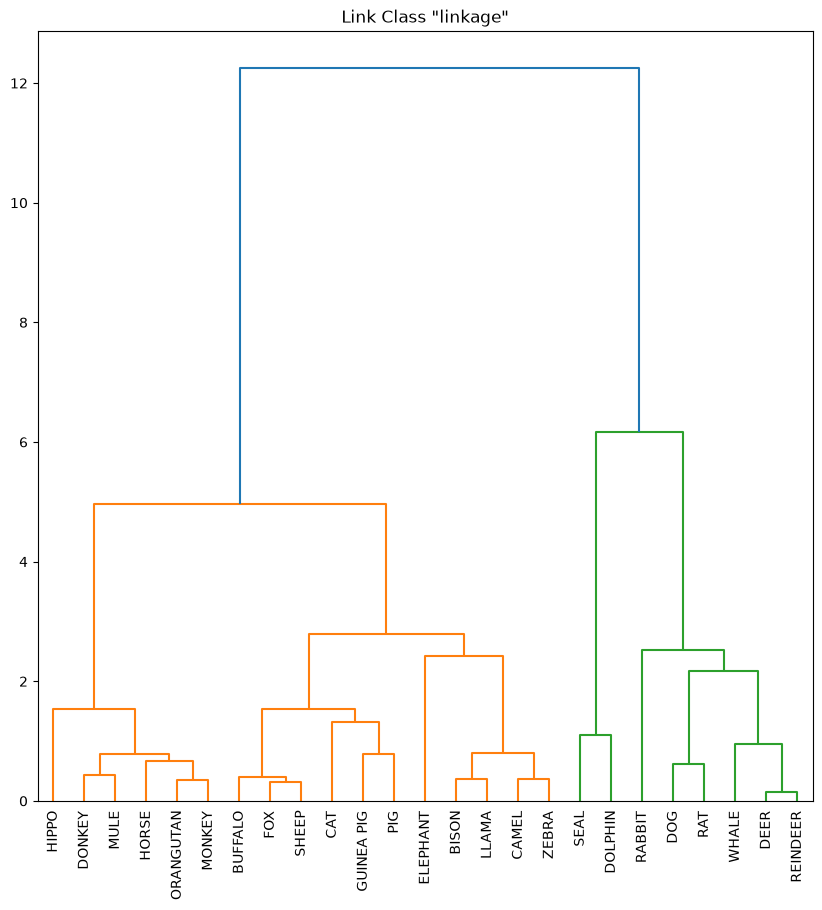

In [68]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

link = "ward"

margin = linkage(
    df_milk_scale,
    method=link
)

plt.figure(figsize=(10,10))

dendrogram(
    margin,
    labels=list(df_milk_scale.index),
    leaf_rotation=90
)

plt.title('Link Class "linkage"')
plt.xticks(rotation=90)
plt.show()

In [72]:
df_nut=pd.read_csv("../Datasets/nutrient.csv",index_col=0)

In [73]:
scaler=StandardScaler().set_output(transform="pandas")
df=scaler.fit_transform(df_nut)
print(df.head())
df_nut_scale=scaler.fit_transform(df_nut)

                energy   protein       fat   calcium      iron
Food_Item                                                     
BEEF BRAISED  1.335059  0.239681  1.314297 -0.456581  0.152385
HAMBURGER     0.378515  0.479361  0.318516 -0.456581  0.222121
BEEF ROAST    2.140569 -0.958723  2.310078 -0.482699 -0.266028
BEEF STEAK    1.687470  0.000000  1.676399 -0.456581  0.152385
BEEF CANNED  -0.275962  0.719042 -0.315163 -0.352109  0.919476


In [74]:
cluster=[2,3,4,5,6,7]
linkage = ["single","ward", "complete", "average"]
score=[]
for i in cluster:
    for l in linkage:
        cluster=AgglomerativeClustering(n_clusters=i,linkage=l)
        cluster.fit(df_nut_scale)
        score.append([i,l,silhouette_score(df_nut_scale,cluster.labels_)])
score_df=pd.DataFrame(score,columns=["cluster","linkage","silhouette_score"]).sort_values(by="silhouette_score",ascending=False)
print(score_df)

    cluster   linkage  silhouette_score
0         2    single          0.448342
4         3    single          0.445319
7         3   average          0.445319
9         4      ward          0.415801
10        4  complete          0.415801
3         2   average          0.413451
5         3      ward          0.403730
6         3  complete          0.403730
14        5  complete          0.400003
15        5   average          0.400003
22        7  complete          0.375569
13        5      ward          0.371724
19        6   average          0.366377
23        7   average          0.366310
18        6  complete          0.359013
17        6      ward          0.359013
21        7      ward          0.334073
8         4    single          0.331116
11        4   average          0.331116
2         2  complete          0.325786
1         2      ward          0.325786
12        5    single          0.240708
16        6    single          0.169526
20        7    single          0.036225


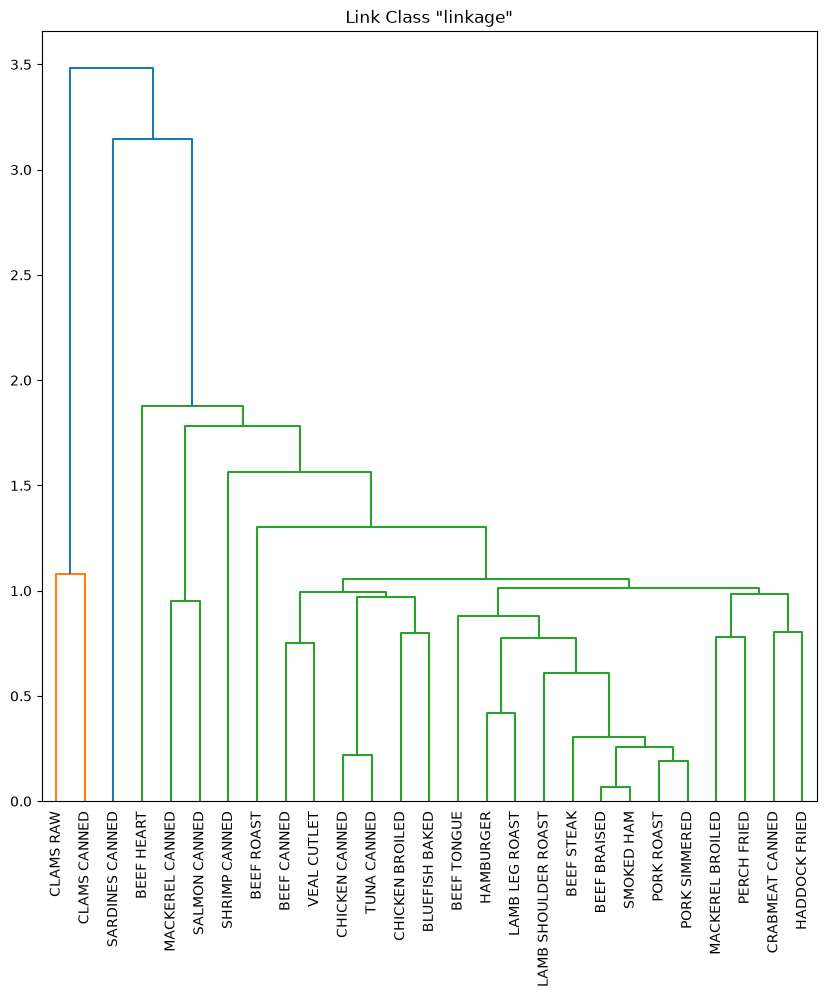

In [77]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
link="single"
margin=linkage(df_nut_scale,method=link)
plt.figure(figsize=(10,10))
dendrogram(margin,labels=list(df_nut_scale.index),leaf_rotation=90)
plt.title('Link Class "linkage"')
plt.xticks(rotation=90)
plt.show()